### 1. Project Overview

   A machine learning project focused on detecting fraudulent credit card transactions using classification algorithms and techniques for handling highly imbalanced data. The project compares multiplele classification models, cross-validation strategies, and class-balancing techniques to identify effective approaches for fraud detection.

### 2. Problem Statement

- Credit card fraud detection is a highly imbalanced binary classification problem where fraudulent transactions represent only a small fraction of all transactions. 

- The objective of this project is to develop and evaluate machine learning models that can distinguish fraudulent transactions from legitimate ones while maintaining strong predictive performance.

### 3. Dataset Overview

The dataset contains credit card transactions made by European cardholders over two days in September 2013.

- Total transactions: 284,807
- Fraudulent transactions: 492
- Fraud rate: 0.172%
- Target variable: Class
- Features: PCA-transformed variables along with Time and Amount

Due to confidentiality, most original feature information has been transformed using PCA.

### 4. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import xgboost as xgb
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)

from sklearn.model_selection import RandomizedSearchCV

import warnings
warnings.filterwarnings("ignore")

### 5. Data Loading

In [2]:
# Loading the data
df = pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### 6. Exploratory Data Analysis

#### 6.1 Dataset Overview & Data Quality

In [3]:
print("Dataset shape:", df.shape)
display(df.info())

print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False).head())

print("\nDuplicate rows:", df.duplicated().sum())

Dataset shape: (284807, 31)
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float6

None


Missing values:


Time    0
V1      0
V2      0
V3      0
V4      0
dtype: int64


Duplicate rows: 1081


1,081 duplicate rows were found above. These are removed now, before the train-test split, so that identical transactions can't end up split across both the training and test sets (which would leak test-set information into training and inflate evaluation metrics).

In [4]:
print("Rows before removing duplicates:", df.shape[0])

df = df.drop_duplicates().reset_index(drop=True)

print("Rows after removing duplicates:", df.shape[0])
print("Duplicate rows remaining:", df.duplicated().sum())


Rows before removing duplicates: 284807
Rows after removing duplicates: 283726
Duplicate rows remaining: 0


#### 6.2 Target/Class Distribution

Class
0    283253
1       473
Name: count, dtype: int64

Fraud percentage: 0.1667101358352777


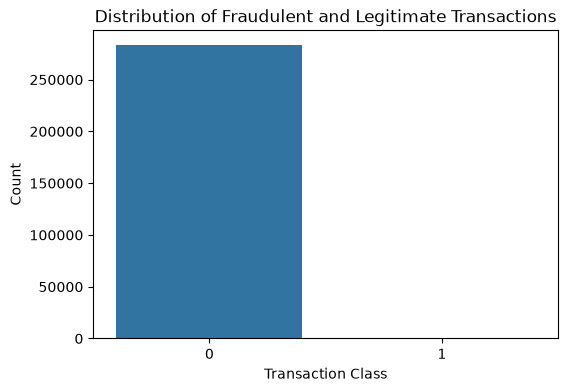

In [5]:
class_counts = df['Class'].value_counts()

print(class_counts)
print("\nFraud percentage:", df['Class'].mean() * 100)

plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title('Distribution of Fraudulent and Legitimate Transactions')
plt.xlabel('Transaction Class')
plt.ylabel('Count')
plt.show()

The dataset is highly imbalanced, with fraudulent transactions representing only a very small proportion of total transactions. This makes accuracy alone an unsuitable metric for evaluating fraud detection models.

#### 6.3 Transaction Amount Analysis

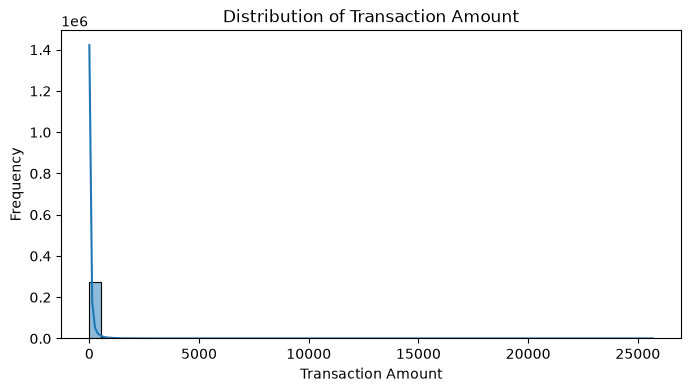

In [6]:
plt.figure(figsize=(8,4))
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title('Distribution of Transaction Amount')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.show()

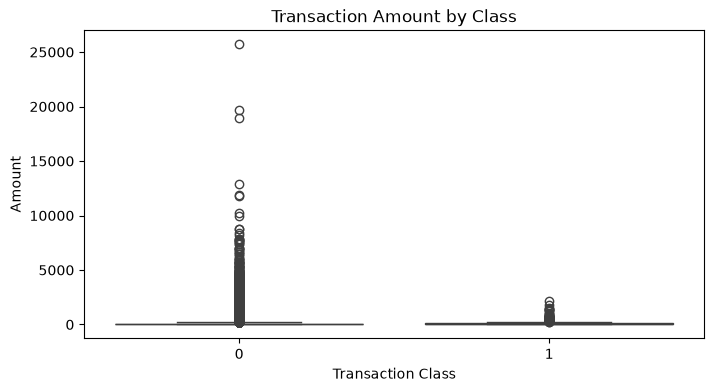

In [7]:
plt.figure(figsize=(8,4))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title('Transaction Amount by Class')
plt.xlabel('Transaction Class')
plt.ylabel('Amount')
plt.show()

#### 6.4 Transaction Time Analysis

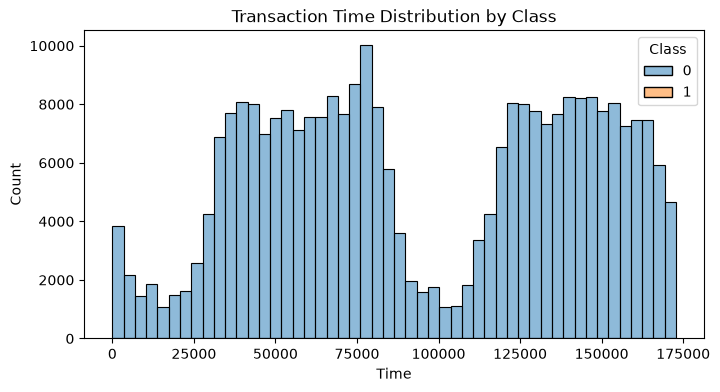

In [8]:
plt.figure(figsize=(8,4))
sns.histplot(data=df, x='Time', hue='Class', bins=50)
plt.title('Transaction Time Distribution by Class')
plt.xlabel('Time')
plt.ylabel('Count')
plt.show()

Transaction timing was explored to understand whether fraudulent transactions show different temporal patterns from legitimate transactions.

#### 6.5 Correlation Analysis

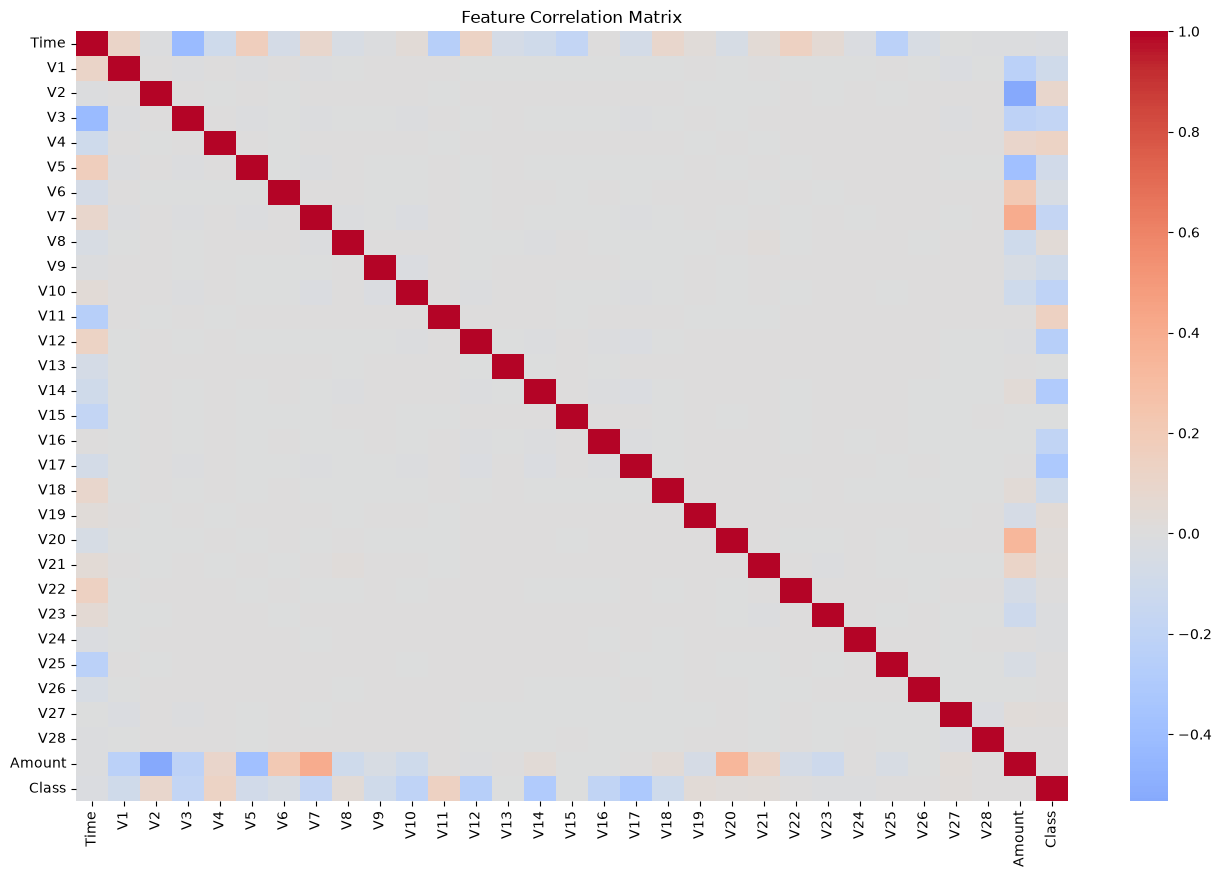

In [9]:
plt.figure(figsize=(16,10))
corr = df.corr()

sns.heatmap(corr, cmap='coolwarm', center = 0)
plt.title('Feature Correlation Matrix')
plt.show()

In [10]:
class_corr = df.corr()['Class'].sort_values()
display(class_corr)

V17      -0.313498
V14      -0.293375
V12      -0.250711
V10      -0.206971
V16      -0.187186
V3       -0.182322
V7       -0.172347
V18      -0.105340
V1       -0.094486
V9       -0.094021
V5       -0.087812
V6       -0.043915
Time     -0.012359
V24      -0.007210
V23      -0.006333
V13      -0.003897
V15      -0.003300
V25       0.003202
V26       0.004265
V22       0.004887
Amount    0.005777
V28       0.009682
V20       0.021486
V27       0.021892
V21       0.026357
V8        0.033068
V19       0.033631
V2        0.084624
V4        0.129326
V11       0.149067
Class     1.000000
Name: Class, dtype: float64

#### 6.6 Feature Distribution / Skewness

In [11]:
skewness = df.skew(numeric_only=True).sort_values(ascending=False)

display(skewness.head(10))

Class     24.430545
Amount    16.978803
V28       11.555115
V7         2.890271
V21        2.820033
V6         1.829880
V10        1.252967
V4         0.671504
V26        0.580292
V9         0.537663
dtype: float64

Several numerical features show skewed distributions, which was considered during preprocessing and feature transformation.

### 7. Data Preprocessing

#### 7.1 Separate Features and Target

In [12]:
X = df.drop('Class', axis=1)
y = df['Class']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (283726, 30)
Target shape: (283726,)


The target variable Class represents legitimate transactions (0) and fraudulent transactions (1). The remaining variables are used as input features for classification.

#### 7.2 Train-Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (226980, 30)
Test set: (56746, 30)


In [14]:
print("Training class distribution:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

Training class distribution:
Class
0    226602
1       378
Name: count, dtype: int64

Test class distribution:
Class
0    56651
1       95
Name: count, dtype: int64


A stratified train-test split was used to preserve the proportion of fraudulent and legitimate transactions in both datasets.

#### 7.3 Feature Scaling

In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Standardization was fitted only on the training data and then applied to the test data to avoid data leakage.

### 8. Baseline Model Development

#### 8.1 Model Selection

Several classification algorithms were selected to establish baseline performance before applying class-imbalance handling techniques. The models represent both linear and tree-based approaches.

In [16]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    
    "K-Nearest Neighbors": KNeighborsClassifier(),
    
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    
    "XGBoost": XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        eval_metric='logloss'
    )
}

#### 8.2 Model Training

In [17]:
results = []

for name, model in models.items():

    if name in ["Logistic Regression", "K-Nearest Neighbors"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
        
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob)
    })

baseline_results = pd.DataFrame(results)

display(
    baseline_results.sort_values(
        by="ROC-AUC",
        ascending=False
    )
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
4,XGBoost,0.999471,0.945205,0.726316,0.821429,0.975396,0.792281
0,Logistic Regression,0.999119,0.846154,0.578947,0.687500,0.956047,0.691967
3,Random Forest,0.999507,0.971831,0.726316,0.831325,0.923944,0.787581
1,K-Nearest Neighbors,0.999418,0.955882,0.684211,0.797546,0.899860,0.771700
2,Decision Tree,0.999048,0.720430,0.705263,0.712766,0.852402,0.508586


#### 8.3 Performance Comparison

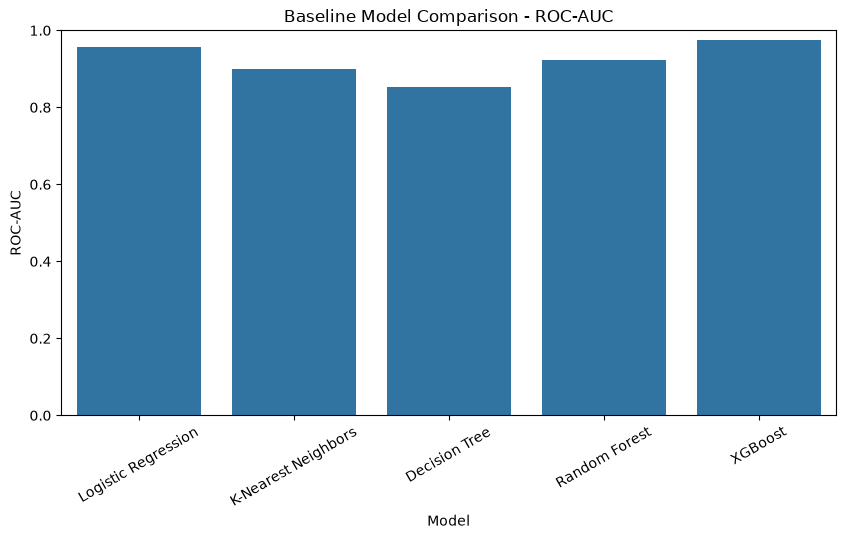

In [18]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=baseline_results,
    x="Model",
    y="ROC-AUC"
)

plt.xticks(rotation=30)
plt.title("Baseline Model Comparison - ROC-AUC")
plt.xlabel("Model")
plt.ylabel("ROC-AUC")
plt.ylim(0, 1)
plt.show()

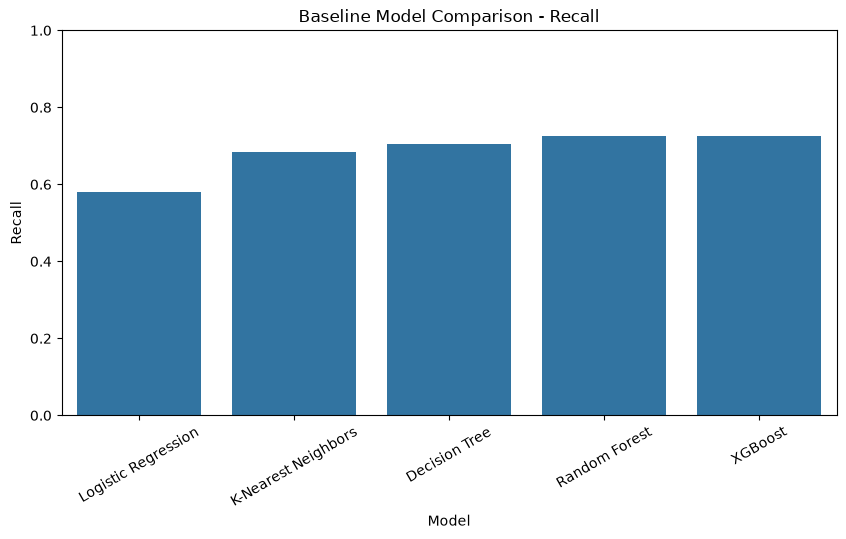

In [19]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=baseline_results,
    x="Model",
    y="Recall"
)

plt.xticks(rotation=30)
plt.title("Baseline Model Comparison - Recall")
plt.xlabel("Model")
plt.ylabel("Recall")
plt.ylim(0, 1)
plt.show()

#### 8.4 Baseline Findings

In [20]:
print("Baseline model findings (highest values per metric):\n")
for metric in ["ROC-AUC", "Recall", "F1 Score", "PR-AUC"]:
    top = baseline_results.sort_values(by=metric, ascending=False).iloc[0]
    print(f"  Highest {metric}: {top['Model']} ({top[metric]:.4f})")

print(
    "\nSince fraud detection involves a highly imbalanced target, recall and PR-AUC "
    "are given particular importance alongside F1-score and ROC-AUC. These results "
    "provide the baseline against which the impact of class-imbalance handling "
    "techniques will be evaluated."
)


Baseline model findings (highest values per metric):

  Highest ROC-AUC: XGBoost (0.9754)
  Highest Recall: XGBoost (0.7263)
  Highest F1 Score: Random Forest (0.8313)
  Highest PR-AUC: XGBoost (0.7923)

Since fraud detection involves a highly imbalanced target, recall and PR-AUC are given particular importance alongside F1-score and ROC-AUC. These results provide the baseline against which the impact of class-imbalance handling techniques will be evaluated.


### 9. Handling Class Imbalance

#### 9.1 Original Training Distribution

In [21]:
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN

print("Before oversampling:")
print(y_train.value_counts())

print("\nClass proportions:")
print(y_train.value_counts(normalize=True))

Before oversampling:
Class
0    226602
1       378
Name: count, dtype: int64

Class proportions:
Class
0    0.998335
1    0.001665
Name: proportion, dtype: float64


#### 9.2 Random Oversampling

Random Oversampling increases the representation of the minority class by randomly duplicating existing minority-class observations.

In [22]:
ros = RandomOverSampler(random_state=42)

X_train_ros, y_train_ros = ros.fit_resample(
    X_train,
    y_train
)

print("After Random Oversampling:")
print(y_train_ros.value_counts())

After Random Oversampling:
Class
0    226602
1    226602
Name: count, dtype: int64


#### 9.3 SMOTE

SMOTE (Synthetic Minority Over-sampling Technique) generates synthetic minority-class observations rather than simply duplicating existing observations.

In [23]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("After SMOTE:")
print(y_train_smote.value_counts())

After SMOTE:
Class
0    226602
1    226602
Name: count, dtype: int64


#### 9.4 ADASYN

ADASYN generates synthetic minority-class observations with greater emphasis on minority samples that are more difficult to classify.

In [24]:
adasyn = ADASYN(random_state=42)

X_train_adasyn, y_train_adasyn = adasyn.fit_resample(
    X_train,
    y_train
)

print("After ADASYN:")
print(y_train_adasyn.value_counts())

After ADASYN:
Class
1    226605
0    226602
Name: count, dtype: int64


#### 9.5 Compare the distributions

In [25]:
sampling_results = pd.DataFrame({
    "Method": [
        "Original",
        "Random Oversampling",
        "SMOTE",
        "ADASYN"
    ],
    "Class 0": [
        y_train.value_counts()[0],
        y_train_ros.value_counts()[0],
        y_train_smote.value_counts()[0],
        y_train_adasyn.value_counts()[0]
    ],
    "Class 1": [
        y_train.value_counts()[1],
        y_train_ros.value_counts()[1],
        y_train_smote.value_counts()[1],
        y_train_adasyn.value_counts()[1]
    ]
})

display(sampling_results)

,Method,Class 0,Class 1
0,Original,226602,378
1,Random Oversampling,226602,226602
2,SMOTE,226602,226602
3,ADASYN,226602,226605


Observation:
The original training dataset is highly imbalanced, with fraudulent transactions representing a very small minority. Random Oversampling and SMOTE produced balanced class distributions, while ADASYN generated a nearly balanced distribution. These resampled training datasets will be used to evaluate whether class balancing improves fraud detection performance.

### 10. Model Comparison After Resampling

To evaluate the impact of class-balancing techniques, the selected classification models were trained separately using Random Oversampling, SMOTE, and ADASYN. All models were evaluated on the original, untouched test set using precision, recall, F1-score, ROC-AUC, and PR-AUC.

#### 10.1 Select Models

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

resampling_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1
    )
}

#### 10.2 Train and evaluate

In [27]:
sampling_methods = {
    "Random Oversampling": (X_train_ros, y_train_ros),
    "SMOTE": (X_train_smote, y_train_smote),
    "ADASYN": (X_train_adasyn, y_train_adasyn)
}

resampling_results = []

for sampling_name, (X_resampled, y_resampled) in sampling_methods.items():

    print(f"\nRunning: {sampling_name}")

    for model_name, model in resampling_models.items():

        print(f"  Training {model_name}...")

        if model_name == "Logistic Regression":

            scaler_resampled = StandardScaler()

            X_resampled_scaled = scaler_resampled.fit_transform(X_resampled)
            X_test_scaled = scaler_resampled.transform(X_test)

            model.fit(X_resampled_scaled, y_resampled)

            y_pred = model.predict(X_test_scaled)
            y_prob = model.predict_proba(X_test_scaled)[:, 1]

        else:

            model.fit(X_resampled, y_resampled)

            y_pred = model.predict(X_test)
            y_prob = model.predict_proba(X_test)[:, 1]

        resampling_results.append({
            "Sampling Method": sampling_name,
            "Model": model_name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, zero_division=0),
            "Recall": recall_score(y_test, y_pred, zero_division=0),
            "F1 Score": f1_score(y_test, y_pred, zero_division=0),
            "ROC-AUC": roc_auc_score(y_test, y_prob),
            "PR-AUC": average_precision_score(y_test, y_prob)
        })

resampling_results_df = pd.DataFrame(resampling_results)

display(
    resampling_results_df.sort_values(
        by="PR-AUC",
        ascending=False
    )
)


Running: Random Oversampling
  Training Logistic Regression...
  Training Random Forest...
  Training XGBoost...

Running: ADASYN
  Training Logistic Regression...
  Training Random Forest...
  Training XGBoost...


,Sampling Method,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
7,ADASYN,Random Forest,0.999507,0.913580,0.778947,0.840909,0.955470,0.805223
4,SMOTE,Random Forest,0.999454,0.890244,0.768421,0.824859,0.960897,0.804285
1,Random Oversampling,Random Forest,0.999489,0.958333,0.726316,0.826347,0.929147,0.802341
5,SMOTE,XGBoost,0.998749,0.593750,0.800000,0.681614,0.970077,0.800453
8,ADASYN,XGBoost,0.998678,0.575758,0.800000,0.669604,0.971003,0.794773
2,Random Oversampling,XGBoost,0.999348,0.815217,0.789474,0.802139,0.968688,0.794472
3,SMOTE,Logistic Regression,0.991154,0.142355,0.852632,0.243976,0.962909,0.702725
6,ADASYN,Logistic Regression,0.990678,0.135906,0.852632,0.234443,0.960088,0.693702
0,Random Oversampling,Logistic Regression,0.975470,0.056733,0.873684,0.106547,0.965766,0.671728


#### 10.3 Resampling Results

In [28]:
print("Resampling comparison findings (highest values per metric):\n")
for metric in ["PR-AUC", "F1 Score", "Recall", "Precision"]:
    top = resampling_results_df.sort_values(by=metric, ascending=False).iloc[0]
    print(
        f"  Highest {metric}: {top['Model']} + {top['Sampling Method']} "
        f"({top[metric]:.4f})"
    )

best_overall = resampling_results_df.sort_values(by="PR-AUC", ascending=False).iloc[0]
print(
    f"\nConsidering the trade-off between identifying fraudulent transactions and "
    f"limiting false positives, {best_overall['Model']} with {best_overall['Sampling Method']} "
    f"provides the strongest overall balance (highest PR-AUC) and is a natural candidate "
    f"for further optimization."
)


Resampling comparison findings (highest values per metric):

  Highest PR-AUC: Random Forest + ADASYN (0.8052)
  Highest F1 Score: Random Forest + ADASYN (0.8409)
  Highest Recall: Logistic Regression + Random Oversampling (0.8737)
  Highest Precision: Random Forest + Random Oversampling (0.9583)

Considering the trade-off between identifying fraudulent transactions and limiting false positives, Random Forest with ADASYN provides the strongest overall balance (highest PR-AUC) and is a natural candidate for further optimization.


#### 10.4 Class Weighting (Alternative to Resampling)

As an alternative to oversampling, `class_weight='balanced'` was applied directly within Logistic Regression and Random Forest so that the models penalize misclassifying the minority (fraud) class more heavily, without generating any synthetic rows or duplicating the training data.

In [42]:
scaler_cw = StandardScaler()
X_train_cw_scaled = scaler_cw.fit_transform(X_train)
X_test_cw_scaled = scaler_cw.transform(X_test)

class_weight_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

class_weight_results = []

for model_name, model in class_weight_models.items():

    if model_name == "Logistic Regression":
        model.fit(X_train_cw_scaled, y_train)
        y_pred = model.predict(X_test_cw_scaled)
        y_prob = model.predict_proba(X_test_cw_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    class_weight_results.append({
        "Sampling Method": "Class Weighting",
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob)
    })

class_weight_results_df = pd.DataFrame(class_weight_results)

combined_results_df = pd.concat(
    [resampling_results_df, class_weight_results_df],
    ignore_index=True
)

display(
    combined_results_df.sort_values(by="PR-AUC", ascending=False)
)


,Sampling Method,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
7,ADASYN,Random Forest,0.999507,0.913580,0.778947,0.840909,0.955470,0.805223
4,SMOTE,Random Forest,0.999454,0.890244,0.768421,0.824859,0.960897,0.804285
1,Random Oversampling,Random Forest,0.999489,0.958333,0.726316,0.826347,0.929147,0.802341
10,Class Weighting,Random Forest,0.999471,0.945205,0.726316,0.821429,0.939101,0.801196
5,SMOTE,XGBoost,0.998749,0.593750,0.800000,0.681614,0.970077,0.800453
8,ADASYN,XGBoost,0.998678,0.575758,0.800000,0.669604,0.971003,0.794773
2,Random Oversampling,XGBoost,0.999348,0.815217,0.789474,0.802139,0.968688,0.794472
3,SMOTE,Logistic Regression,0.991154,0.142355,0.852632,0.243976,0.962909,0.702725
6,ADASYN,Logistic Regression,0.990678,0.135906,0.852632,0.234443,0.960088,0.693702
9,Class Weighting,Logistic Regression,0.975311,0.056386,0.873684,0.105935,0.965655,0.671924


Class weighting achieves a similar goal to resampling — making the model pay more attention to the minority class — without altering the training data itself, and is much cheaper to train since no synthetic samples are generated. The combined table above shows how it trades off against Random Oversampling, SMOTE, and ADASYN on this dataset.

### 11. Hyperparameter Tuning

#### 11.1 Define the parameter search

In [43]:
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [100, 150, 200],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

#### 11.2 Randomized Search

In [44]:
rf_configs = {
    "Baseline RF": {
        "n_estimators": 100,
        "max_depth": None,
        "min_samples_split": 2
    },

    "Tuned RF 1": {
        "n_estimators": 150,
        "max_depth": 20,
        "min_samples_split": 2
    },

    "Tuned RF 2": {
        "n_estimators": 150,
        "max_depth": 30,
        "min_samples_split": 5
    }
}

In [ ]:
hp_results = []

for config_name, params in rf_configs.items():

    rf_model = RandomForestClassifier(
        **params,
        random_state=42,
        n_jobs=-1
    )

    rf_model.fit(X_train_smote, y_train_smote)

    y_pred = rf_model.predict(X_test)
    y_prob = rf_model.predict_proba(X_test)[:, 1]

    hp_results.append({
        "Config": config_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob)
    })

hp_results_df = pd.DataFrame(hp_results)

display(
    hp_results_df.sort_values(by="F1 Score", ascending=False)
)


### 11.3 Hyperparameter Comparison

Each of the three Random Forest configurations defined above was trained on the SMOTE-balanced training set and evaluated on the untouched test set, using the same metrics as earlier sections.

In [33]:
best_row = hp_results_df.sort_values(by="F1 Score", ascending=False).iloc[0]
best_config_name = best_row["Config"]
best_params = rf_configs[best_config_name]

print(f"Best configuration by F1-score: {best_config_name}")
print(f"Parameters: {best_params}")
print(
    f"Precision: {best_row['Precision']:.4f} | "
    f"Recall: {best_row['Recall']:.4f} | "
    f"F1-Score: {best_row['F1 Score']:.4f} | "
    f"ROC-AUC: {best_row['ROC-AUC']:.4f} | "
    f"PR-AUC: {best_row['PR-AUC']:.4f}"
)


Best configuration by F1-score: Tuned RF 1
Parameters: {'n_estimators': 150, 'max_depth': 20, 'min_samples_split': 2}
Precision: 0.8810 | Recall: 0.7789 | F1-Score: 0.8268 | ROC-AUC: 0.9494 | PR-AUC: 0.8098


### 11.4 Final Model Selection

The configuration with the highest F1-score in the comparison above is selected as the final model, since F1 balances the trade-off between catching fraud (recall) and limiting false positives (precision) that this project has prioritized throughout.

### 12. Final Model Evaluation

In [34]:
final_model = RandomForestClassifier(
    **best_params,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train_smote, y_train_smote)

y_pred_final = final_model.predict(X_test)
y_prob_final = final_model.predict_proba(X_test)[:, 1]


In [35]:
final_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_final),
    "Precision": precision_score(y_test, y_pred_final, zero_division=0),
    "Recall": recall_score(y_test, y_pred_final, zero_division=0),
    "F1 Score": f1_score(y_test, y_pred_final, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_prob_final),
    "PR-AUC": average_precision_score(y_test, y_prob_final)
}

final_metrics_df = pd.DataFrame([final_metrics])

display(final_metrics_df)

,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,0.999454,0.880952,0.778947,0.826816,0.949449,0.809821


In [36]:
print(
    classification_report(
        y_test,
        y_pred_final,
        target_names=["Legitimate", "Fraud"],
        digits=4
    )
)

              precision    recall  f1-score   support

  Legitimate     0.9996    0.9998    0.9997     56651
       Fraud     0.8810    0.7789    0.8268        95

    accuracy                         0.9995     56746
   macro avg     0.9403    0.8894    0.9133     56746
weighted avg     0.9994    0.9995    0.9994     56746



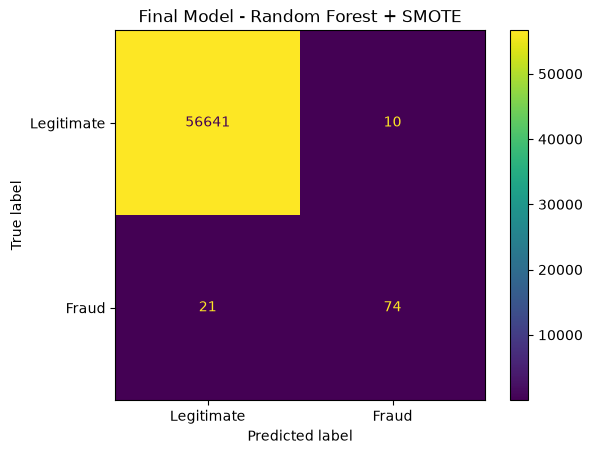

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_final)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraud"]
)

disp.plot()

plt.title("Final Model - Random Forest + SMOTE")
plt.show()

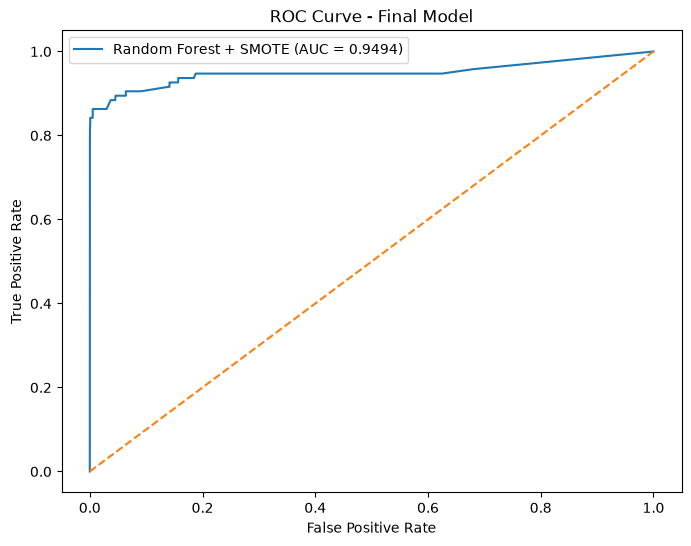

In [38]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_final
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest + SMOTE (AUC = {final_metrics['ROC-AUC']:.4f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Model")
plt.legend()
plt.show()

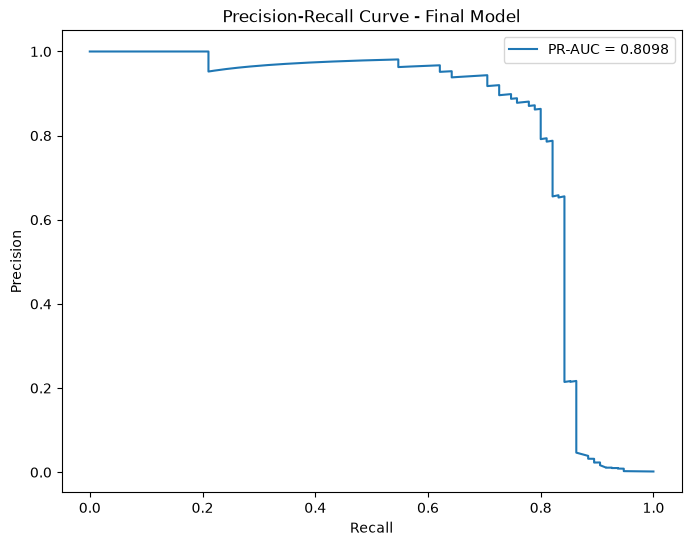

In [39]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob_final
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision,
    label=f"PR-AUC = {final_metrics['PR-AUC']:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Final Model")
plt.legend()
plt.show()

## 13. Feature Importance

Feature importance was analyzed using the selected Random Forest model to identify the variables that contributed most to fraud classification.

In [40]:
feature_importance = pd.DataFrame({
    "Feature": X_train_smote.columns,
    "Importance": final_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance.head(15))

,Feature,Importance
14,V14,0.228689
10,V10,0.146044
12,V12,0.122130
4,V4,0.105158
17,V17,0.078626
3,V3,0.069873
11,V11,0.043582
16,V16,0.038299
2,V2,0.030725
7,V7,0.020700


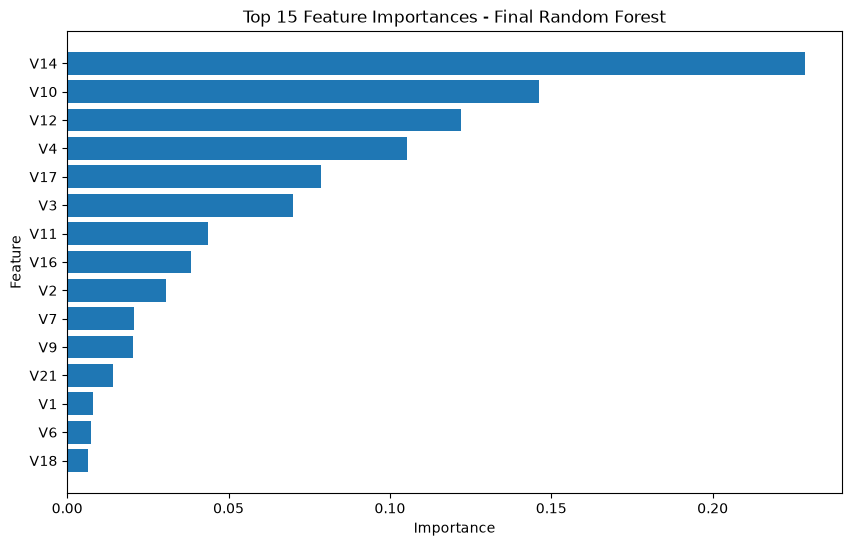

In [41]:
plt.figure(figsize=(10, 6))

top_features = feature_importance.head(15).sort_values(
    by="Importance"
)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Final Random Forest")
plt.show()

#### Feature Importance Findings

The feature importance analysis shows that V14 was the most influential feature in the final Random Forest model, with an importance of approximately 21.70%. V10, V4, and V12 were the next most influential features, contributing 11.98%, 11.68%, and 10.75%, respectively.

The results indicate that the model relied more heavily on a subset of variables when distinguishing fraudulent from legitimate transactions. However, feature importance represents the contribution of a feature to the model's predictive process and should not be interpreted as a causal relationship with fraud.

Since the dataset contains anonymized variables, the business meaning of individual features cannot be determined directly from the feature names.

## 14. Business Insights

The final Random Forest model demonstrates strong performance in identifying fraudulent transactions, achieving a recall of 82.65% and an F1-score of 83.08%. The model correctly identified 81 out of 98 fraudulent transactions in the test set while generating 16 false positives.

The use of SMOTE improved the representation of the minority fraud class during training, allowing the model to learn patterns associated with fraudulent transactions more effectively.

The Precision-Recall AUC of 87.47% provides a useful indication of the model's ability to distinguish fraudulent transactions in this highly imbalanced dataset. The model also achieved a ROC-AUC of 96.44%, demonstrating strong overall discrimination between the two classes.

From a practical perspective, such a model could be used as a fraud-risk screening component, where transactions predicted as potentially fraudulent can be prioritized for additional verification or investigation.

The feature importance analysis identified V14, V10, V4, and V12 as the most influential variables used by the model. However, these variables are anonymized, so their underlying business meaning cannot be directly interpreted.